In [7]:
from google.colab import files

uploaded = files.upload()

Saving data (1).csv to data (1).csv


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("data (1).csv", header=None)

print(df.shape)
print(df.head())

(6900, 257)
   0    1    2    3    4    5    6    7    8    9    ...  247  248  249  250  \
0    0   94   96    5    0  -11    9  -12    8   -9  ...  -38   24  -36   24   
1    0   96 -128    5    0   11  -21    9  -20    8  ...   33  -44   32  -43   
2    0   96 -128    5    0    5   23    5   20    5  ...    4   26    3   25   
3    0   96 -128    5    0   17    2   17    2   17  ...   45   17   44   15   
4    0   96 -128    5    0   15    5   14    4   13  ...   40   25   39   22   

   251  252  253  254  255  256  
0  -33   22  -34   19  -33   14  
1   29  -43   26  -43   23  -44  
2    4   24    4   23    4   21  
3   45   13   45   13   45   11  
4   40   20   38   18   35   17  

[5 rows x 257 columns]


In [10]:
y = df.iloc[:, 0].to_numpy()
X = df.iloc[:, 1:257].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6900, 256)
y shape: (6900,)


In [11]:
labels, counts = np.unique(y, return_counts=True)

print("Labels:", labels)
print("Counts:", counts)

Labels: [0 1 2 3 4 5 6 7 8 9]
Counts: [690 690 690 690 690 690 690 690 690 690]


In [12]:
max_val = X.max(axis=1)
min_val = X.min(axis=1)

amplitude = (max_val - min_val) / 2

print("Amplitude shape:", amplitude.shape)
print("First 10 amplitudes:")
print(amplitude[:10])

Amplitude shape: (6900,)
First 10 amplitudes:
[ 79.5 112.  112.  112.  112.  112.  112.   76.  112.   56.5]


In [13]:
print("Number of samples:", len(amplitude))
print("Minimum amplitude:", amplitude.min())
print("Maximum amplitude:", amplitude.max())
print("Mean amplitude:", amplitude.mean())

Number of samples: 6900
Minimum amplitude: 21.5
Maximum amplitude: 112.0
Mean amplitude: 86.92355072463768


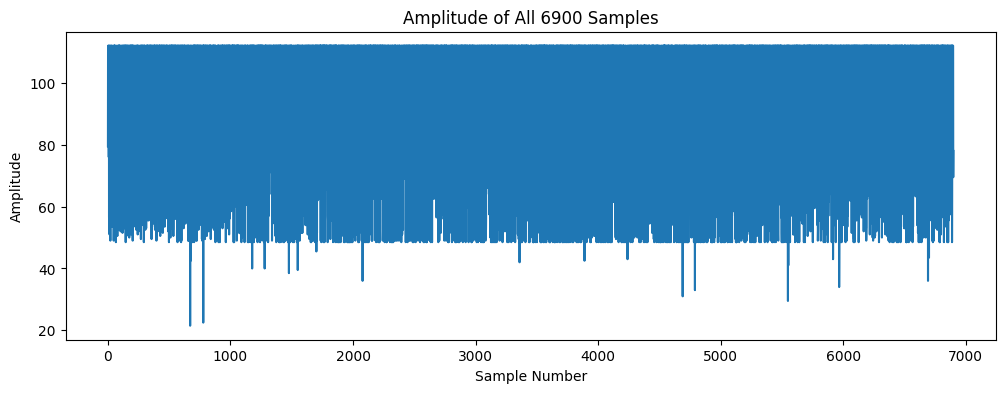

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(amplitude)

plt.title("Amplitude of All 6900 Samples")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.show()

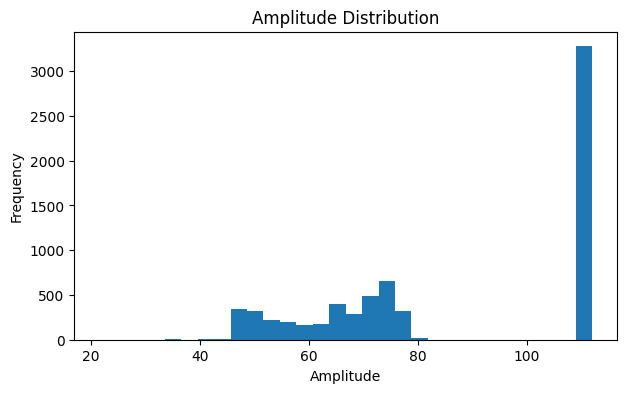

In [15]:
plt.figure(figsize=(7, 4))

plt.hist(amplitude, bins=30)

plt.title("Amplitude Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Frequency")

plt.show()

In [16]:
X_2D = X.reshape(6900, 16, 16)

print("X_2D shape:", X_2D.shape)

X_2D shape: (6900, 16, 16)


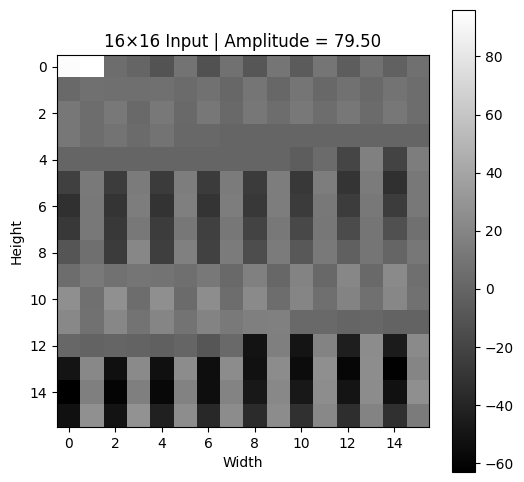

In [17]:
plt.figure(figsize=(6, 6))

plt.imshow(X_2D[0], cmap="gray")

plt.title(
    f"16×16 Input | Amplitude = {amplitude[0]:.2f}"
)

plt.xlabel("Width")
plt.ylabel("Height")

plt.colorbar()

plt.show()

In [18]:
X_cnn = X_2D.reshape(6900, 16, 16, 1)

print("CNN input shape:", X_cnn.shape)

CNN input shape: (6900, 16, 16, 1)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5520, 16, 16, 1)
X_test: (1380, 16, 16, 1)
y_train: (5520,)
y_test: (1380,)


In [20]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

model = Sequential([

    Input(shape=(16, 16, 1)),

    Conv2D(
        16,
        (2, 2),
        padding="same",
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Flatten(),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,210 (129.73 KB)

 Trainable params: 33,210 (129.73 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1096 - loss: 2.8425 - val_accuracy: 0.1431 - val_loss: 2.2415
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1368 - loss: 2.2374 - val_accuracy: 0.1784 - val_loss: 2.1858
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1624 - loss: 2.1759 - val_accuracy: 0.2011 - val_loss: 2.1000
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1954 - loss: 2.0927 - val_accuracy: 0.2101 - val_loss: 2.1238
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2319 - loss: 2.0097 - val_accuracy: 0.2428 - val_loss: 1.9502
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2382 - loss: 1.9517 - val_accuracy: 0.2446 - val_loss: 1.9119
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2382 - loss: 1.9193 - val_accuracy: 0.2437 - val_loss: 1.8894
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2430 - loss: 1.9059 - val_accuracy: 

In [23]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2435 - loss: 1.8768
Test Accuracy: 0.24347825348377228
Test Accuracy (%): 24.347825348377228


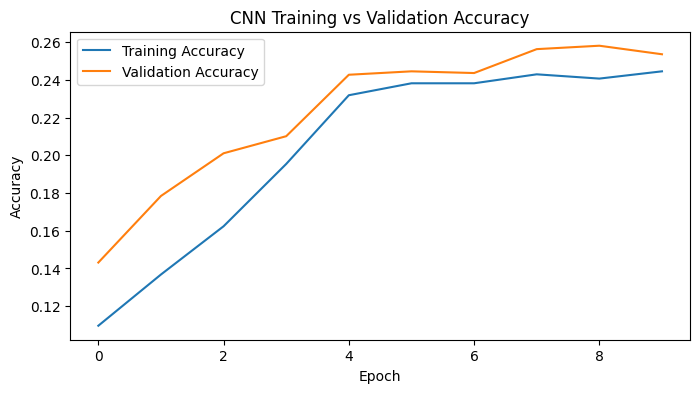

In [24]:
plt.figure(figsize=(8, 4))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("CNN Training vs Validation Accuracy")

plt.legend()

plt.show()

In [25]:
import tensorflow as tf

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

feature_map = feature_model.predict(X_test[:1])

print("Feature map shape:", feature_map.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Feature map shape: (1, 16, 16, 16)


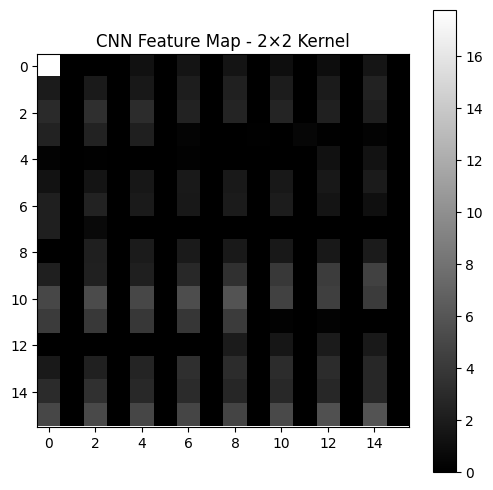

In [26]:
plt.figure(figsize=(6, 6))

plt.imshow(
    feature_map[0, :, :, 0],
    cmap="gray"
)

plt.title("CNN Feature Map - 2×2 Kernel")

plt.colorbar()

plt.show()